# LTAF Database — Pipeline de Detecção de Arritmia

Dataset: PhysioNet `ltafdb/1.0.0` — 84 gravações Holter 24h, 2 canais ECG, 128 Hz, 12-bit.

**Pipeline em 3 estágios:**
1. **Segmentação adaptativa** — detecção de onset/offset por derivada do sinal
2. **CNN de morfologia** — classifica cada batimento em N / A / V
3. **BiLSTM de ritmo** — classifica janelas de 10s em Normal vs Anormal

## 1 — Setup

In [1]:
import sys
import subprocess

subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-r', 'requirements.txt'
])

0

## 2 — Imports e Configurações

In [2]:
import warnings
warnings.filterwarnings('ignore')

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb.processing as wp

from scipy.signal import butter, filtfilt, savgol_filter
from scipy.interpolate import interp1d
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Filtro passa-banda
def bandpass(sig, fs, low=0.5, high=40):
    b, a = butter(3, [low / (fs / 2), high / (fs / 2)], btype='band')
    return filtfilt(b, a, sig)

## 3 — Carregamento do Sinal e Anotações

In [3]:
from pathlib import Path

DATA_DIR = Path("data")

# Lista todos os pacientes disponíveis (qualquer arquivo .atr na pasta)
patient_ids = sorted(
    p.stem for p in DATA_DIR.glob("*.atr")
)
print(f"Pacientes encontrados: {len(patient_ids)} → {patient_ids}")

records = []
for pid in patient_ids:
    try:
        ann  = wfdb.rdann(str(DATA_DIR / pid), 'atr')
        rec  = wfdb.rdrecord(str(DATA_DIR / pid))
        fs   = rec.fs
        dur_h = rec.sig_len / fs / 3600

        symbols  = np.array(ann.symbol)
        aux      = ann.aux_note
        beat_mask = np.isin(symbols, ['N', 'A', 'V'])
        beats    = symbols[beat_mask]
        samples  = ann.sample[beat_mask]

        # FC mediana via intervalos RR
        rr_sec   = np.diff(samples) / fs
        rr_sec   = rr_sec[(rr_sec > 0.3) & (rr_sec < 2.5)]  # fisiológico
        fc_med   = 60 / np.median(rr_sec) if len(rr_sec) > 0 else np.nan
        fc_std   = 60 / rr_sec.std()      if len(rr_sec) > 0 else np.nan

        # Ritmos presentes
        rhythms  = [a.strip() for a in aux if a.strip().startswith('(')]
        rhythm_set = set(rhythms)

        # Proporção de batimentos anormais
        n_beats  = len(beats)
        n_normal = (beats == 'N').sum()
        pct_abn  = round(100 * (1 - n_normal / n_beats), 1) if n_beats > 0 else np.nan

        records.append({
            'patient':    pid,
            'dur_h':      round(dur_h, 2),
            'n_beats':    n_beats,
            'n_N':        int(n_normal),
            'n_A':        int((beats == 'A').sum()),
            'n_V':        int((beats == 'V').sum()),
            'pct_abn':    pct_abn,
            'fc_med_bpm': round(fc_med, 1),
            'fc_std':     round(fc_std, 3),
            'rhythms':    ', '.join(sorted(rhythm_set)),
        })

    except Exception as e:
        print(f"  [{pid}] ERRO: {e}")

df_inv = pd.DataFrame(records).sort_values('pct_abn', ascending=False).reset_index(drop=True)

print(f"\n── Inventário ({len(df_inv)} pacientes) ──")
print(df_inv.to_string(index=False))

# Salva para referência futura
df_inv.to_csv("data/inventory.csv", index=False)
print("\nSalvo em data/inventory.csv")

Pacientes encontrados: 84 → ['00', '01', '03', '05', '06', '07', '08', '10', '100', '101', '102', '103', '104', '105', '11', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '12', '120', '121', '122', '13', '15', '16', '17', '18', '19', '20', '200', '201', '202', '203', '204', '205', '206', '207', '208', '21', '22', '23', '24', '25', '26', '28', '30', '32', '33', '34', '35', '37', '38', '39', '42', '43', '44', '45', '47', '48', '49', '51', '53', '54', '55', '56', '58', '60', '62', '64', '65', '68', '69', '70', '71', '72', '74', '75']

── Inventário (84 pacientes) ──
patient  dur_h  n_beats    n_N   n_A   n_V  pct_abn  fc_med_bpm  fc_std                                  rhythms
     22  25.68   124758  95430 12677 16651     23.5        87.3 283.340 (AB, (AFIB, (B, (N, (SBR, (SVTA, (T, (VT
     23  25.65    99954  81870 15677  2407     18.1        73.8 254.362 (AB, (AFIB, (B, (N, (SBR, (SVTA, (T, (VT
    103  24.00   151656 127444 22046  2166     16.0       120.0 309

In [4]:
# Cálculo de RR_MEAN e RR_STD sobre todos os pacientes do LTAFDB
import os, json

rr_params_path = Path('models/rr_params.json')

if rr_params_path.exists():
    rr_params = json.load(open(rr_params_path))
    RR_MEAN = rr_params['rr_mean']
    RR_STD  = rr_params['rr_std']
    print(f"rr_params carregado — mean: {RR_MEAN:.4f}s | std: {RR_STD:.4f}s ({60/RR_MEAN:.1f} bpm)")
else:
    all_rr = []
    for pid in patient_ids:
        try:
            rec    = wfdb.rdrecord(str(DATA_DIR / pid))
            signal = rec.p_signal[:, 0]
            fs     = rec.fs
            xqrs   = wp.XQRS(sig=signal, fs=fs)
            xqrs.detect()
            rr = np.diff(xqrs.qrs_inds) / fs
            rr = rr[(rr > 0.3) & (rr < 2.5)]
            all_rr.append(rr)
            print(f"[{pid}] {len(rr)} intervalos RR")
        except Exception as e:
            print(f"[{pid}] ERRO: {e}")

    all_rr  = np.concatenate(all_rr)
    RR_MEAN = float(all_rr.mean())
    RR_STD  = float(all_rr.std())
    print(f"\nRR_MEAN: {RR_MEAN:.4f}s | RR_STD: {RR_STD:.4f}s ({60/RR_MEAN:.1f} bpm)")

    os.makedirs('models', exist_ok=True)
    json.dump({'rr_mean': RR_MEAN, 'rr_std': RR_STD}, open(rr_params_path, 'w'))
    print("Salvo em models/rr_params.json")


rr_params carregado — mean: 0.0541s | std: 138.8682s (1109.3 bpm)


In [6]:
# Carregar sinal e anotações — multi-paciente
SELECTED_PATIENTS = ['22','23','103','204','122','121','100','51','200','25','74','62','03','72','28']

all_signals, all_fs, all_dfs = {}, {}, {}

for pid in SELECTED_PATIENTS:
    record = wfdb.rdrecord(f'data/{pid}')
    ann    = wfdb.rdann(f'data/{pid}', 'atr')
    fs_p   = record.fs
    signal = record.p_signal[:, 0]

    # ── Detecta picos QRS pelo sinal bruto ──────────────────────
    xqrs = wp.XQRS(sig=signal, fs=fs_p)
    xqrs.detect()
    qrs_samples = xqrs.qrs_inds
    # ────────────────────────────────────────────────────────────

    # Associa cada pico detectado ao label mais próximo do .atr
    ann_mask    = np.isin(ann.symbol, ['N', 'A', 'V'])
    ann_samples = ann.sample[ann_mask]
    ann_symbols = np.array(ann.symbol)[ann_mask]

    tol = int(0.05 * fs_p)
    matched_symbols = []
    for s in qrs_samples:
        diffs = np.abs(ann_samples - s)
        idx   = np.argmin(diffs)
        matched_symbols.append(ann_symbols[idx] if diffs[idx] <= tol else 'U')

    matched_symbols = np.array(matched_symbols)
    beat_mask_xqrs  = matched_symbols != 'U'

    df_p = pd.DataFrame({
        'sample':   qrs_samples,
        'symbol':   matched_symbols,
        'aux_note': [''] * len(qrs_samples),
        'patient':  pid,
    })

    # Propaga ritmo do .atr por tempo
    ann_rhythm = pd.DataFrame({'sample': ann.sample, 'aux_note': ann.aux_note})
    ann_rhythm = ann_rhythm[ann_rhythm['aux_note'].str.strip().str.startswith('(')]
    ann_rhythm = ann_rhythm.sort_values('sample').drop_duplicates(subset='sample').reset_index(drop=True)

    bins   = [-1] + list(ann_rhythm['sample']) + [len(signal)]
    labels = [''] + list(ann_rhythm['aux_note'])

    df_p['rhythm'] = pd.cut(
        df_p['sample'],
        bins=bins,
        labels=labels,
        ordered=False
    ).astype(str)

    INVALID_RHYTHMS = ['Aux', 'MISSB']
    df_p = df_p[~df_p['rhythm'].isin(INVALID_RHYTHMS)].reset_index(drop=True)

    all_signals[pid] = signal
    all_fs[pid]      = fs_p
    all_dfs[pid]     = df_p

    print(f"[{pid}] XQRS: {len(qrs_samples)} picos | com label: {beat_mask_xqrs.sum()} | sem match: {(~beat_mask_xqrs).sum()}")
    print(df_p[df_p['symbol'] != 'U']['symbol'].value_counts().to_string())

df = pd.concat(all_dfs.values(), ignore_index=True)

Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
[22] XQRS: 132512 picos | com label: 124470 | sem match: 8042
symbol
N    95297
V    16501
A    12672
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
[23] XQRS: 100356 picos | com label: 99341 | sem match: 1015
symbol
N    81853
A    15677
V     1811
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
[103] XQRS: 151624 picos | com label: 150697 | sem match: 927
symbol
N    126726
A     21902
V      2069
Learning initial signal parameters...
Found 8 beats during learning. Initializing using learned parameters
Running QRS detection...
QRS detection complete.
[204] XQRS: 137348 picos | com label: 133892 | sem match: 3456
symbo

## 4 — Estágio 1: Segmentação Adaptativa

Usando os samples do `.atr` como âncoras (picos QRS), detecta onset e offset de cada onda via derivada suavizada (Savitzky-Golay). Interpolação cúbica para tamanho fixo de 200 amostras (~1.56s a 128Hz).

**Label: N = 0, A = 1, V = 2** (morfologia por batimento)
**Normal:** `symbol == 'N'` AND `rhythm == '(N'`

In [7]:
def detect_wave_bounds(sig, peak, fs, search_pre=0.25, search_post=0.40, smooth_window=11):
    """Retorna (onset, offset) em índices de amostra via derivada suavizada."""
    pre  = int(search_pre * fs)
    post = int(search_post * fs)
    left  = max(0, peak - pre)
    right = min(len(sig) - 1, peak + post)
    seg = sig[left:right]
    if len(seg) < smooth_window + 2:
        return left, right
    dseg = savgol_filter(seg, smooth_window, 2, deriv=1)
    peak_local = peak - left
    left_deriv   = np.abs(dseg[:peak_local])
    onset_local  = np.argmin(left_deriv) if len(left_deriv) > 0 else 0
    right_deriv  = np.abs(dseg[peak_local:])
    offset_local = peak_local + (np.argmin(right_deriv) if len(right_deriv) > 0 else 0)
    return left + onset_local, left + offset_local

In [8]:
# Segmentação — todos os pacientes selecionados
CACHE_DIR = Path("cache"); CACHE_DIR.mkdir(exist_ok=True)

CACHE_SEGS = CACHE_DIR / "segments.npy"
CACHE_META = CACHE_DIR / "seg_meta.pkl"

TARGET_LEN = 200  # amostras por segmento (ajustável)

if CACHE_SEGS.exists() and CACHE_META.exists():
    print("Cache encontrado — carregando...")
    segments = np.load(CACHE_SEGS)
    seg_meta = pd.read_pickle(CACHE_META)  # colunas: peak, patient, symbol, rhythm
    seg_peaks    = seg_meta['peak'].values
    seg_patients = seg_meta['patient'].values
    print(f"Segmentos: {segments.shape}")

else:
    all_segs, all_meta = [], []

    for pid in SELECTED_PATIENTS:
        signal = all_signals[pid]
        fs     = all_fs[pid]
        beats_p = all_dfs[pid][all_dfs[pid]['symbol'].isin(['N','A','V'])].copy().reset_index(drop=True)

        for _, row in beats_p.iterrows():
            peak = row['sample']
            onset, offset = detect_wave_bounds(signal, peak, fs)
            seg = signal[onset:offset]
            if len(seg) < 10:
                continue
            x_orig = np.linspace(0, 1, len(seg))
            x_new  = np.linspace(0, 1, TARGET_LEN)
            all_segs.append(interp1d(x_orig, seg, kind='cubic')(x_new))
            all_meta.append({'peak': peak, 'patient': pid, 'symbol': row['symbol'], 'rhythm': row['rhythm']})

        print(f"[{pid}] {len(beats_p)} batimentos segmentados")

    segments = np.array(all_segs)
    seg_meta = pd.DataFrame(all_meta)
    seg_peaks    = seg_meta['peak'].values
    seg_patients = seg_meta['patient'].values

    np.save(CACHE_SEGS, segments)
    seg_meta.to_pickle(CACHE_META)
    print(f"\nCache salvo. Segmentos: {segments.shape}")

Cache encontrado — carregando...
Segmentos: (1591573, 200)


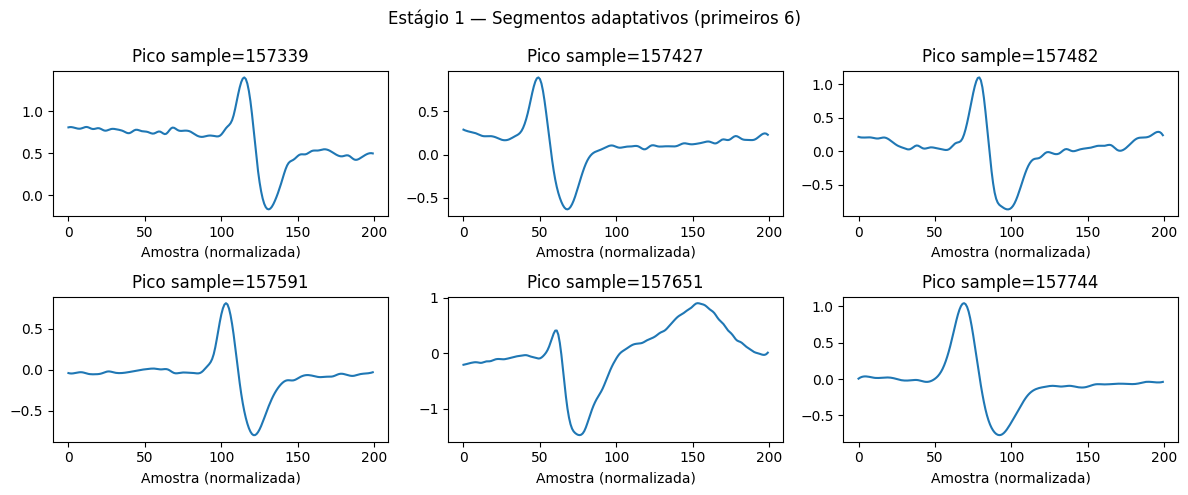

In [9]:
# Verificação visual — primeiros 6 segmentos
fig, axes = plt.subplots(2, 3, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.plot(segments[i])
    ax.set_title(f"Pico sample={seg_peaks[i]}")
    ax.set_xlabel("Amostra (normalizada)")
plt.suptitle("Estágio 1 — Segmentos adaptativos (primeiros 6)")
plt.tight_layout()
plt.show()

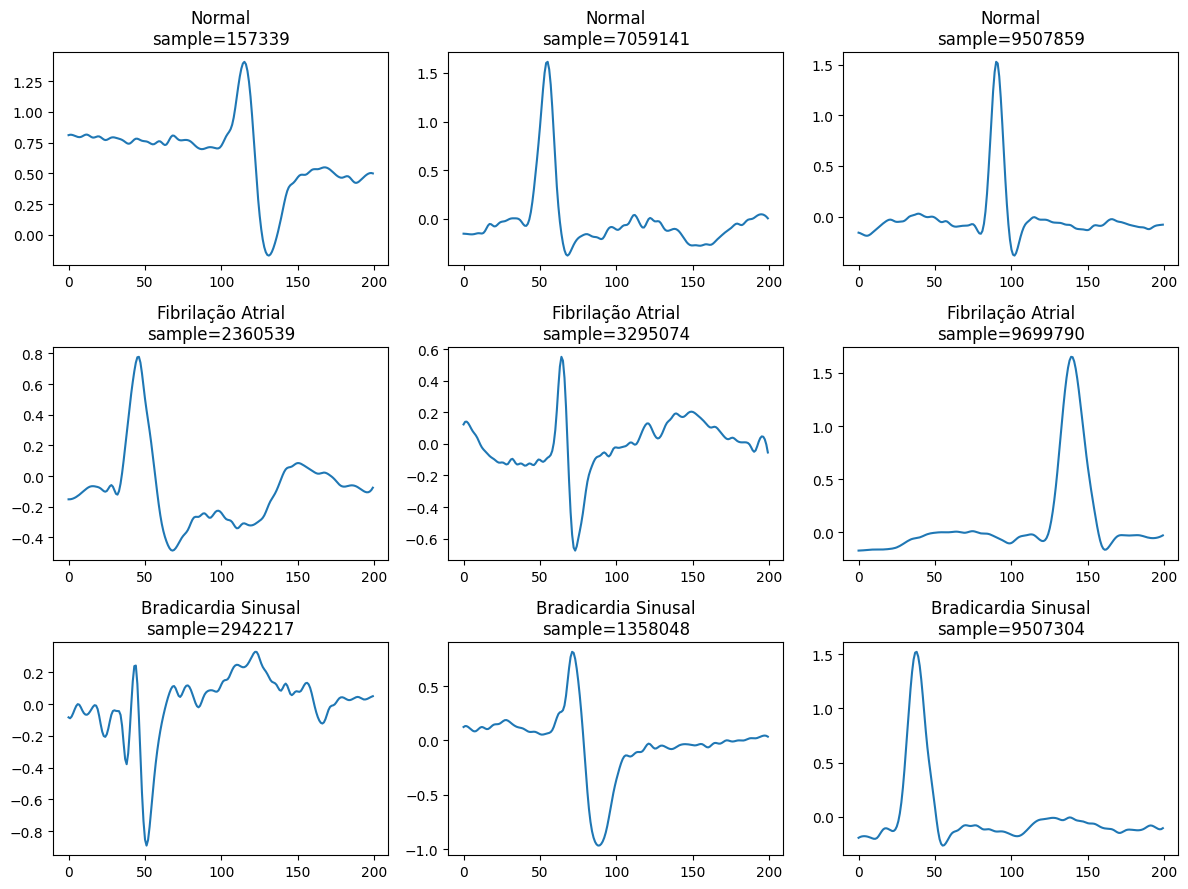

In [10]:
# Verificação por ritmo — Normal, AFIB, Bradicardia
def plot_rhythm_comparison(df, segments, seg_peaks):
    ritmos = {'(N': 'Normal', '(AFIB': 'Fibrilação Atrial', '(SBR': 'Bradicardia Sinusal'}
    fig, axes = plt.subplots(len(ritmos), 3, figsize=(12, 9))
    for row, (ritmo, label) in enumerate(ritmos.items()):
        samples = df[df['rhythm'] == ritmo]['sample'].values
        idxs = np.linspace(0, len(samples) - 1, 3, dtype=int)
        for col, idx in enumerate(idxs):
            s = samples[idx]
            seg_idx = np.searchsorted(seg_peaks, s)
            if seg_idx >= len(segments):
                continue
            axes[row, col].plot(segments[seg_idx])
            axes[row, col].set_title(f"{label}\nsample={s}")
    plt.tight_layout()
    plt.show()

plot_rhythm_comparison(df, segments, seg_peaks)

## 5 — Estágio 2: CNN de Morfologia (N / A / V)

CNN 1D com 3 blocos Conv+BN+MaxPool → GlobalAveragePooling → Dense(64) → Dropout(0.5) → Softmax(3).

Input: segmentos de 200 amostras (saída do Estágio 1), filtrados e normalizados por batimento.
Split: 80% treino → SMOTE → 20% validação (sem SMOTE) | 20% teste (sem SMOTE).

In [11]:
# Associar labels do df aos segmentos via seg_peaks
beats = df[df['symbol'].isin(['N', 'A', 'V'])].copy().reset_index(drop=True)
peak_to_label = dict(zip(beats['sample'].values, beats['symbol'].values))
y2   = np.array([peak_to_label[p] for p in seg_peaks if p in peak_to_label])
mask = np.array([p in peak_to_label for p in seg_peaks])
X2   = segments[mask]

# Filtro e normalização
fs = list(all_fs.values())[0]  # todos os pacientes do LTAFDB têm 128 Hz
X2 = np.array([bandpass(x, fs) for x in X2])
X2 = (X2 - X2.mean(axis=1, keepdims=True)) / (X2.std(axis=1, keepdims=True) + 1e-8)

le2 = LabelEncoder()
y2_enc = le2.fit_transform(y2)
print(f"Shape: {X2.shape}, Classes: {le2.classes_}, Dist: {np.bincount(y2_enc)}")

Shape: (963882, 200), Classes: ['A' 'N' 'V'], Dist: [ 34864 902912  26106]


In [12]:
X2_flat = X2.reshape(len(X2), -1)

# Split principal (teste)
X2_train_f, X2_test_f, y2_train_raw, y2_test = train_test_split(
    X2_flat, y2_enc, test_size=0.2, random_state=42, stratify=y2_enc)

# Split validação (do treino, antes do SMOTE)
X2_train_f, X2_val_f, y2_train_raw, y2_val = train_test_split(
    X2_train_f, y2_train_raw, test_size=0.2, random_state=42, stratify=y2_train_raw)

# SMOTE só no treino
X2_train_bal, y2_train_bal = SMOTE(random_state=42).fit_resample(X2_train_f, y2_train_raw)

X2_train = X2_train_bal.reshape(-1, 200, 1)
X2_val   = X2_val_f.reshape(-1, 200, 1)
X2_test  = X2_test_f.reshape(-1, 200, 1)

print(f"Treino: {X2_train.shape}, Val: {X2_val.shape}, Teste: {X2_test.shape}")
print(f"Dist treino: {np.bincount(y2_train_bal)}, Dist val: {np.bincount(y2_val)}, Dist teste: {np.bincount(y2_test)}")

Treino: (1733589, 200, 1), Val: (154221, 200, 1), Teste: (192777, 200, 1)
Dist treino: [577863 577863 577863], Dist val: [  5578 144466   4177], Dist teste: [  6973 180583   5221]


In [13]:
model2 = models.Sequential([
    layers.Input(shape=(200, 1)),
    layers.Conv1D(32, kernel_size=5, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),
    layers.Conv1D(64, kernel_size=5, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling1D(2),
    layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
])

model2.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])
model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 200, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 50, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,547 (174.01 KB)

 Trainable params: 44,099 (172.26 KB)

 Non-trainable params: 448 (1.75 KB)

In [14]:
callbacks2 = [
    EarlyStopping(patience=10, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.5)
]

history2 = model2.fit(
    X2_train, y2_train_bal,
    epochs=30,
    batch_size=64,
    validation_data=(X2_val, y2_val),
    callbacks=callbacks2
)

Epoch 1/30
27088/27088 ━━━━━━━━━━━━━━━━━━━━ 319s 12ms/step - accuracy: 0.7595 - loss: 0.6083 - val_accuracy: 0.7493 - val_loss: 0.6392 - learning_rate: 0.0010
Epoch 2/30
27088/27088 ━━━━━━━━━━━━━━━━━━━━ 313s 12ms/step - accuracy: 0.7910 - loss: 0.5347 - val_accuracy: 0.8521 - val_loss: 0.3595 - learning_rate: 0.0010
Epoch 3/30
27088/27088 ━━━━━━━━━━━━━━━━━━━━ 308s 11ms/step - accuracy: 0.8019 - loss: 0.5076 - val_accuracy: 0.9046 - val_loss: 0.2747 - learning_rate: 0.0010
Epoch 4/30
27088/27088 ━━━━━━━━━━━━━━━━━━━━ 308s 11ms/step - accuracy: 0.8095 - loss: 0.4888 - val_accuracy: 0.8906 - val_loss: 0.3055 - learning_rate: 0.0010
Epoch 5/30
27088/27088 ━━━━━━━━━━━━━━━━━━━━ 329s 12ms/step - accuracy: 0.8146 - loss: 0.4744 - val_accuracy: 0.8708 - val_loss: 0.3791 - learning_rate: 0.0010
Epoch 6/30
27088/27088 ━━━━━━━━━━━━━━━━━━━━ 324s 12ms/step - accuracy: 0.8188 - loss: 0.4636 - val_accuracy: 0.8229 - val_loss: 0.4805 - learning_rate: 0.0010
Epoch 7/30
27088/27088 ━━━━━━━━━━━━━━━━━━━━ 32

6025/6025 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


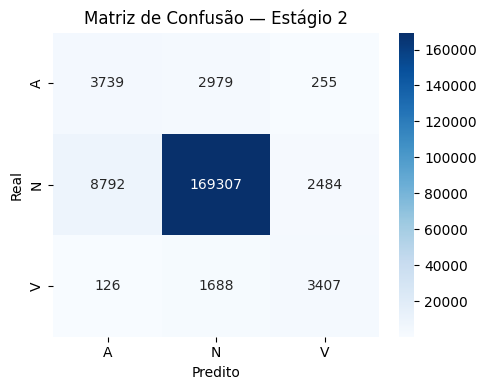

              precision    recall  f1-score   support

           A       0.30      0.54      0.38      6973
           N       0.97      0.94      0.96    180583
           V       0.55      0.65      0.60      5221

    accuracy                           0.92    192777
   macro avg       0.61      0.71      0.65    192777
weighted avg       0.94      0.92      0.92    192777

AUC A: 0.8734
AUC N: 0.8805
AUC V: 0.9146


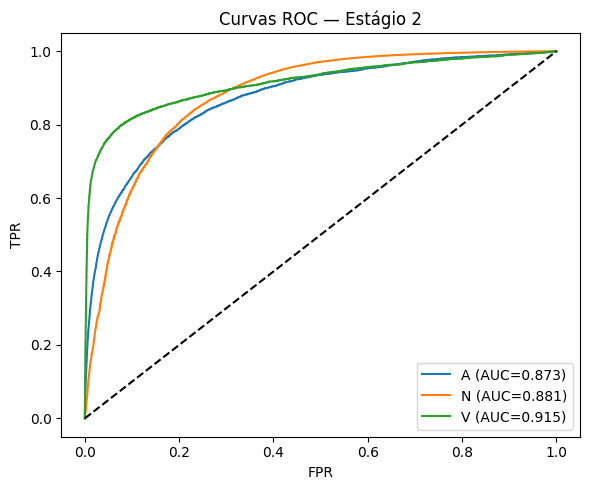

A → Sensitivity: 0.536 | Specificity: 0.952
N → Sensitivity: 0.938 | Specificity: 0.617
V → Sensitivity: 0.653 | Specificity: 0.985


In [15]:
# Avaliação — Estágio 2
y2_pred_proba = model2.predict(X2_test)
y2_pred = np.argmax(y2_pred_proba, axis=1)
classes = le2.classes_

# Confusion Matrix
cm2 = confusion_matrix(y2_test, y2_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm2, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
ax.set_xlabel('Predito'); ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão — Estágio 2')
plt.tight_layout(); plt.show()

print(classification_report(y2_test, y2_pred, target_names=classes))

# AUC
y2_test_bin = label_binarize(y2_test, classes=[0, 1, 2])
auc2_scores = roc_auc_score(y2_test_bin, y2_pred_proba, average=None)
for c, auc in zip(classes, auc2_scores):
    print(f"AUC {c}: {auc:.4f}")

# Curvas ROC
fig, ax = plt.subplots(figsize=(6, 5))
for i, c in enumerate(classes):
    fpr, tpr, _ = roc_curve(y2_test_bin[:, i], y2_pred_proba[:, i])
    ax.plot(fpr, tpr, label=f"{c} (AUC={auc2_scores[i]:.3f})")
ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Curvas ROC — Estágio 2')
ax.legend(); plt.tight_layout(); plt.show()

# Sensitivity / Specificity
for i, c in enumerate(classes):
    tp = cm2[i, i]; fn = cm2[i, :].sum() - tp
    fp = cm2[:, i].sum() - tp; tn = cm2.sum() - tp - fn - fp
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    print(f"{c} → Sensitivity: {sens:.3f} | Specificity: {spec:.3f}")

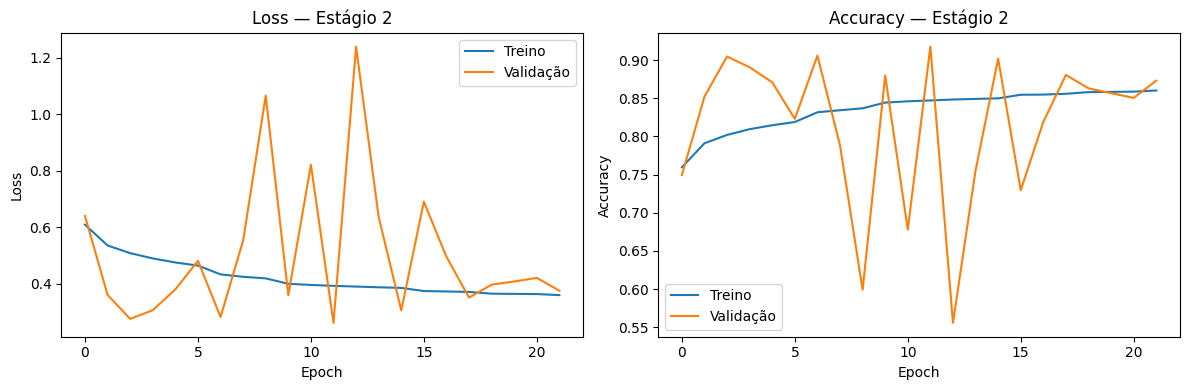

In [16]:
# Curvas de loss — Estágio 2
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history2.history['loss'], label='Treino')
axes[0].plot(history2.history['val_loss'], label='Validação')
axes[0].set_title('Loss — Estágio 2')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].plot(history2.history['accuracy'], label='Treino')
axes[1].plot(history2.history['val_accuracy'], label='Validação')
axes[1].set_title('Accuracy — Estágio 2')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.tight_layout(); plt.show()

In [17]:
import os
os.makedirs('models', exist_ok=True)
model2.save('models/clean_model2_morphology.keras')
print("model2 salvo")

model2 salvo


In [18]:
model2_check = tf.keras.models.load_model('models/clean_model2_morphology.keras')

# Compara predições do modelo salvo vs modelo em memória
sample = X2_test[:10]
pred_original = np.argmax(model2.predict(sample), axis=1)
pred_loaded   = np.argmax(model2_check.predict(sample), axis=1)

print("Original: ", pred_original)
print("Carregado:", pred_loaded)
print("Idênticos:", np.all(pred_original == pred_loaded))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
Original:  [1 1 1 1 1 1 1 1 1 1]
Carregado: [1 1 1 1 1 1 1 1 1 1]
Idênticos: True


## 6 — Estágio 3: BiLSTM de Ritmo (Normal vs Anormal)

Janelas de 10s. Cada janela contém uma sequência de batimentos com 2 features: `[pred_symbol, rr_interval]`.

- `pred_symbol`: label do Estágio 2 (N=0, A=1, V=2)
- `rr`: intervalo entre batimentos em segundos (normalizado)

**Label da janela:** 0 = Normal (`N + (N` em todos os batimentos), 1 = Anormal (qualquer outro)

Arquitetura: BiLSTM(64) → Dropout → BiLSTM(32) → Dropout → Dense(32) → Sigmoid(1)

In [19]:
# Predições do model2 sobre todos os segmentos
X2_all = segments[mask]
X2_all = np.array([bandpass(x, fs) for x in X2_all])
X2_all = (X2_all - X2_all.mean(axis=1, keepdims=True)) / (X2_all.std(axis=1, keepdims=True) + 1e-8)
pred_labels_all = le2.inverse_transform(
    np.argmax(model2.predict(X2_all.reshape(-1, 200, 1), batch_size=512), axis=1)
)
peak_to_pred = dict(zip(seg_peaks[mask], pred_labels_all))

# Montar janelas de 10s
WINDOW_SEC = 10
beats = df[df['symbol'].isin(['N', 'A', 'V']) & ~df['rhythm'].isin(['Aux', 'MISSB'])].copy().reset_index(drop=True)
print(beats['rhythm'].value_counts().head(10))
print(repr(beats['rhythm'].iloc[0]))
beats['label']       = ((beats['symbol'] == 'N') & (beats['rhythm'] == '(N')).astype(int)
fs = list(all_fs.values())[0]
beats['rr']          = beats['sample'].diff().fillna(0) / fs
beats['window_id'] = beats['patient'].astype(str) + '_' + (beats['sample'] // (WINDOW_SEC * fs)).astype(int).astype(str)
beats['pred_symbol'] = beats['sample'].map(peak_to_pred)
beats = beats.dropna(subset=['pred_symbol']).reset_index(drop=True)

X_seq, y_seq = [], []
for wid, group in beats.groupby('window_id'):
    if len(group) < 3:
        continue
    symbol_enc = group['pred_symbol'].map({'N': 0, 'A': 1, 'V': 2}).values
    rr         = group['rr'].values
    label_bin  = group['label'].values
    seq = np.stack([symbol_enc, rr], axis=1)
    y_seq.append(0 if label_bin.mean() >= 0.90 else 1)
    X_seq.append(seq)

print(f"Janelas: {len(X_seq)}, Anormais: {sum(y_seq)}, Normais: {len(y_seq) - sum(y_seq)}")

1883/1883 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step
rhythm
(AFIB    864263
(N       587207
(SBR      43572
(AB       17599
(B        16229
(SVTA      6656
(T         5729
(VT        1346
(IVR        103
Name: count, dtype: int64
'(N'
Janelas: 103880, Anormais: 80662, Normais: 23218


In [20]:
# Padding e normalização do RR
MAX_BEATS = max(len(s) for s in X_seq)
X_pad = pad_sequences(X_seq, maxlen=MAX_BEATS, dtype='float32', padding='post', value=0.0)
y_arr = np.array(y_seq)

X_pad[:, :, 1] = (X_pad[:, :, 1] - RR_MEAN) / (RR_STD + 1e-8)

print(f"Shape: {X_pad.shape}")

Shape: (103880, 31, 2)


In [21]:
# Split + SMOTE (apenas no treino)
X_flat = X_pad.reshape(len(X_pad), -1)

X3_train_f, X3_test_f, y3_train_raw, y3_test = train_test_split(
    X_flat, y_arr, test_size=0.2, random_state=42, stratify=y_arr)

X3_train_f, X3_val_f, y3_train_raw, y3_val = train_test_split(
    X3_train_f, y3_train_raw, test_size=0.2, random_state=42, stratify=y3_train_raw)

print(f"Total janelas: {len(y_arr)}")
print(f"Normais: {(y_arr == 0).sum()} | Anormais: {(y_arr == 1).sum()}")
print(f"Após split treino — Normais: {(y3_train_raw == 0).sum()} | Anormais: {(y3_train_raw == 1).sum()}")

X3_train_bal, y3_train_bal = SMOTE(random_state=42).fit_resample(X3_train_f, y3_train_raw)

X3_train = X3_train_bal.reshape(-1, MAX_BEATS, 2)
X3_val   = X3_val_f.reshape(-1, MAX_BEATS, 2)
X3_test  = X3_test_f.reshape(-1, MAX_BEATS, 2)

print(f"Treino: {X3_train.shape}, Val: {X3_val.shape}, Teste: {X3_test.shape}")
print(f"Dist treino: {np.bincount(y3_train_bal)}, Dist teste: {np.bincount(y3_test)}")

Total janelas: 103880
Normais: 23218 | Anormais: 80662
Após split treino — Normais: 14859 | Anormais: 51624
Treino: (103248, 31, 2), Val: (16621, 31, 2), Teste: (20776, 31, 2)
Dist treino: [51624 51624], Dist teste: [ 4644 16132]


In [22]:
model3 = models.Sequential([
    layers.Input(shape=(MAX_BEATS, 2)),
    layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
    layers.Dropout(0.3),
    layers.Bidirectional(layers.LSTM(32)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model3.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 31, 128)        │        34,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 31, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,633 (303.25 KB)

 Trainable params: 77,633 (303.25 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
callbacks3 = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.5)
]

history3 = model3.fit(
    X3_train, y3_train_bal,
    epochs=30,
    batch_size=64,
    validation_data=(X3_val, y3_val),
    callbacks=callbacks3
)

Epoch 1/30
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.6360 - loss: 0.6292 - val_accuracy: 0.6399 - val_loss: 0.5584 - learning_rate: 0.0010
Epoch 2/30
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.7184 - loss: 0.5447 - val_accuracy: 0.6883 - val_loss: 0.5125 - learning_rate: 0.0010
Epoch 3/30
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.7556 - loss: 0.4947 - val_accuracy: 0.6939 - val_loss: 0.5280 - learning_rate: 0.0010
Epoch 4/30
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.7627 - loss: 0.4857 - val_accuracy: 0.7293 - val_loss: 0.4808 - learning_rate: 0.0010
Epoch 5/30
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.7661 - loss: 0.4792 - val_accuracy: 0.7241 - val_loss: 0.4852 - learning_rate: 0.0010
Epoch 6/30
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.7698 - loss: 0.4752 - val_accuracy: 0.7267 - val_loss: 0.4958 - learning_rate: 0.0010
Epoch 7/30
1614/1614 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accura

650/650 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step


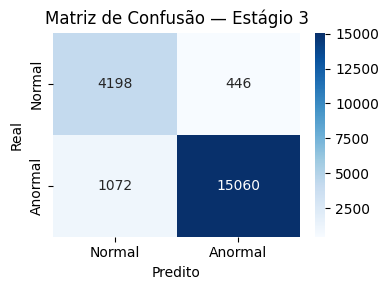

              precision    recall  f1-score   support

      Normal       0.80      0.90      0.85      4644
     Anormal       0.97      0.93      0.95     16132

    accuracy                           0.93     20776
   macro avg       0.88      0.92      0.90     20776
weighted avg       0.93      0.93      0.93     20776

AUC: 0.9736


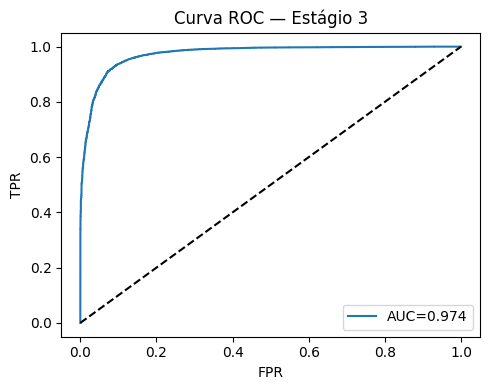

Sensitivity: 0.934 | Specificity: 0.904


In [24]:
# Avaliação — Estágio 3
y3_pred_proba = model3.predict(X3_test).flatten()
y3_pred = (y3_pred_proba >= 0.5).astype(int)

# Confusion Matrix
cm3 = confusion_matrix(y3_test, y3_pred)
fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm3, annot=True, fmt='d',
            xticklabels=['Normal', 'Anormal'],
            yticklabels=['Normal', 'Anormal'], cmap='Blues')
ax.set_xlabel('Predito'); ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão — Estágio 3')
plt.tight_layout(); plt.show()

print(classification_report(y3_test, y3_pred, target_names=['Normal', 'Anormal']))

auc3 = roc_auc_score(y3_test, y3_pred_proba)
print(f"AUC: {auc3:.4f}")

# Curva ROC
fpr, tpr, _ = roc_curve(y3_test, y3_pred_proba)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f'AUC={auc3:.3f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Curva ROC — Estágio 3')
plt.legend(); plt.tight_layout(); plt.show()

tp = cm3[1, 1]; fn = cm3[1, 0]; fp = cm3[0, 1]; tn = cm3[0, 0]
print(f"Sensitivity: {tp / (tp + fn):.3f} | Specificity: {tn / (tn + fp):.3f}")

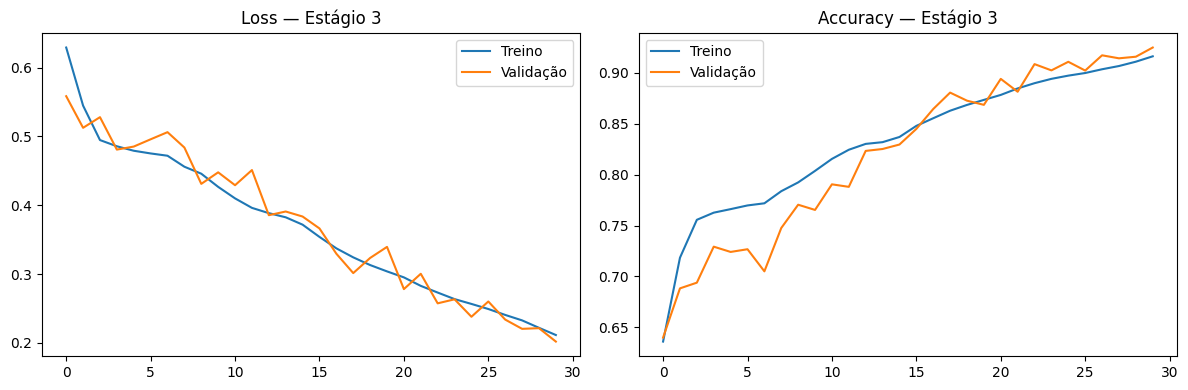

In [25]:
# Curvas de loss — Estágio 3
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history3.history['loss'], label='Treino')
axes[0].plot(history3.history['val_loss'], label='Validação')
axes[0].set_title('Loss — Estágio 3'); axes[0].legend()

axes[1].plot(history3.history['accuracy'], label='Treino')
axes[1].plot(history3.history['val_accuracy'], label='Validação')
axes[1].set_title('Accuracy — Estágio 3'); axes[1].legend()

plt.tight_layout(); plt.show()

325/325 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


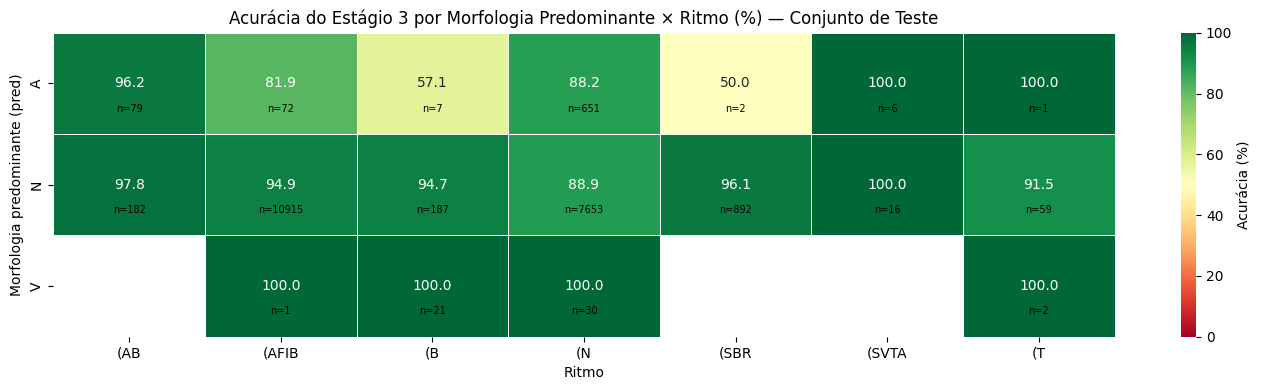

In [26]:
# Rastrear índices do split para alinhar metadados com conjunto de teste
window_records = []
for wid, group in beats.groupby('window_id'):
    if len(group) < 3:
        continue
    window_records.append({
        'dominant_morph':  group['pred_symbol'].mode()[0],
        'dominant_rhythm': group['rhythm'].mode()[0],
        'y_true': 0 if group['label'].values.all() else 1
    })

df_windows = pd.DataFrame(window_records).iloc[:len(y_arr)].reset_index(drop=True)

# Refazer o mesmo split da Célula 3 com índices rastreados
indices = np.arange(len(y_arr))
idx_train, idx_test = train_test_split(indices, test_size=0.2, random_state=42, stratify=y_arr)
idx_train, idx_val  = train_test_split(idx_train, test_size=0.2, random_state=42, stratify=y_arr[idx_train])

df_test = df_windows.iloc[idx_test].copy()
X_test_aligned = X_pad[idx_test]

df_test['y_pred']  = (model3.predict(X_test_aligned, batch_size=64).flatten() >= 0.5).astype(int)
df_test['correct'] = (df_test['y_true'] == df_test['y_pred']).astype(int)

pivot        = df_test.groupby(['dominant_morph', 'dominant_rhythm'])['correct'].agg(['mean', 'count']).reset_index()
pivot['mean'] = (pivot['mean'] * 100).round(1)
acc_matrix   = pivot.pivot(index='dominant_morph', columns='dominant_rhythm', values='mean')
count_matrix = pivot.pivot(index='dominant_morph', columns='dominant_rhythm', values='count')

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(acc_matrix, annot=True, fmt='.1f', cmap='RdYlGn',
            vmin=0, vmax=100, ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Acurácia (%)'})
for i in range(acc_matrix.shape[0]):
    for j in range(acc_matrix.shape[1]):
        val = count_matrix.iloc[i, j]
        if not np.isnan(val):
            ax.text(j + 0.5, i + 0.75, f'n={int(val)}',
                    ha='center', va='center', fontsize=7, color='black')
ax.set_title('Acurácia do Estágio 3 por Morfologia Predominante × Ritmo (%) — Conjunto de Teste')
ax.set_xlabel('Ritmo'); ax.set_ylabel('Morfologia predominante (pred)')
plt.tight_layout(); plt.show()

In [27]:
import os

os.makedirs('models', exist_ok=True)
MODEL2_PATH = 'models/clean_model2_morphology_final.keras'

if os.path.exists(MODEL2_PATH):
    model2 = tf.keras.models.load_model(MODEL2_PATH)
    print("model2 carregado do disco")
else:
    # [células de treino do model2 aqui]
    model2.save(MODEL2_PATH)
    print("model2 treinado e salvo")

model2 treinado e salvo


In [28]:
MODEL3_PATH = 'models/clean_model3_rhythm_final.keras'

if os.path.exists(MODEL3_PATH):
    model3 = tf.keras.models.load_model(MODEL3_PATH)
    print("model3 carregado do disco")
else:
    # [células de treino do model3 aqui]
    model3.save(MODEL3_PATH)
    print("model3 treinado e salvo")

model3 treinado e salvo


In [29]:
import joblib; joblib.dump(le2, 'models/le2.pkl')

['models/le2.pkl']

In [30]:
# rr_params.json já foi salvo na Seção 3 com valores populacionais (todos os pacientes)
# Nada a fazer aqui.
